In [21]:
import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import lightweaver as lw 
import h5py

In [6]:
filename = '/dat/milic/SUSI_modeling/atm_extended_ssd_angle_80synth_full_0.fits'

In [7]:
spectrum_ssd = fits.open(filename)[0].data
print(spectrum_ssd.shape)

(1024, 401, 1001)


In [8]:
ll = fits.open(filename)[1].data
print(ll)

[392.8   392.802 392.804 ... 394.796 394.798 394.8  ]


In [12]:
ll_air = lw.vac_to_air(ll)

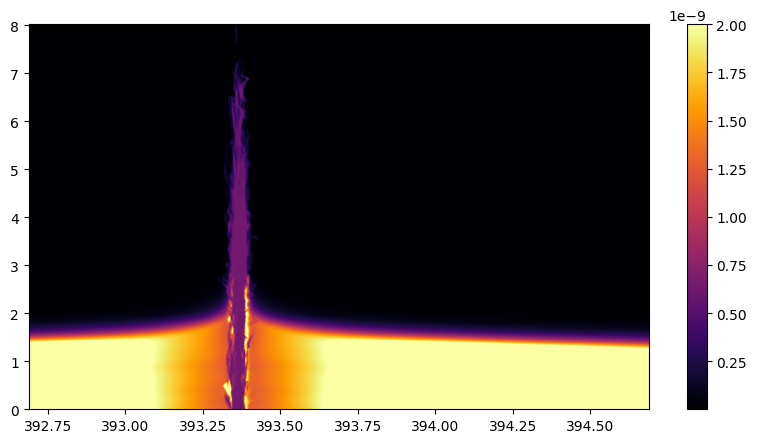

In [13]:
plt.figure(figsize=(10,5))
plt.imshow(spectrum_ssd[0,:,:],cmap='inferno',origin='lower', extent=[ll_air[0], ll_air[-1], 0, spectrum_ssd.shape[1]*0.02], aspect='auto', \
           norm='linear', vmin=1E-12, vmax=2e-9)
plt.colorbar()


In [14]:
# Find average spectrum and average spectrum in time:
I_mean_ssd = np.mean(spectrum_ssd, axis=(1,2))
I_mean_over_time_ssd = np.mean(spectrum_ssd, axis=0)


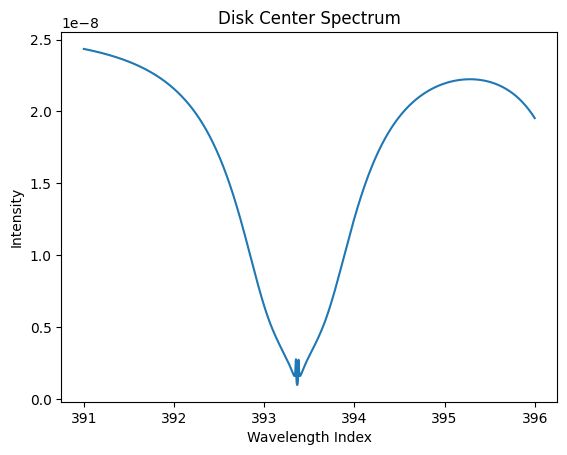

In [15]:
# Let's try to find the maximum intensity in the mean spectrum from lw from the disk center, for normalization.
# you might have to calculate this one on your own! 
lw_1d = fits.open('disk_center_test.fits')
diskcenter_spectrum = lw_1d[0].data
ll_lw = lw_1d[1].data
plt.plot(ll_lw,diskcenter_spectrum)
plt.xlabel('Wavelength Index')
plt.ylabel('Intensity')
plt.title('Disk Center Spectrum')
plt.show()

In [16]:
# Pick the intensity closest to the 394.72 
target_wavelength = 394.72
closest_index = np.argmin(np.abs(ll_lw - target_wavelength))
closest_intensity = diskcenter_spectrum[closest_index]
closest_wavelength = ll_lw[closest_index]
print(f"Closest wavelength to {target_wavelength} is {closest_wavelength} with intensity {closest_intensity}")

Closest wavelength to 394.72 is 394.72 with intensity 2.1014179832113937e-08


In [17]:
# Normalize our cubes to this value:
spectrum_ssd /= np.max(diskcenter_spectrum)
I_mean_ssd /= np.max(diskcenter_spectrum)
I_mean_over_time_ssd /= np.max(diskcenter_spectrum)

Text(0.5, 1.0, 'Normalized Spectrum at Height z = 170')

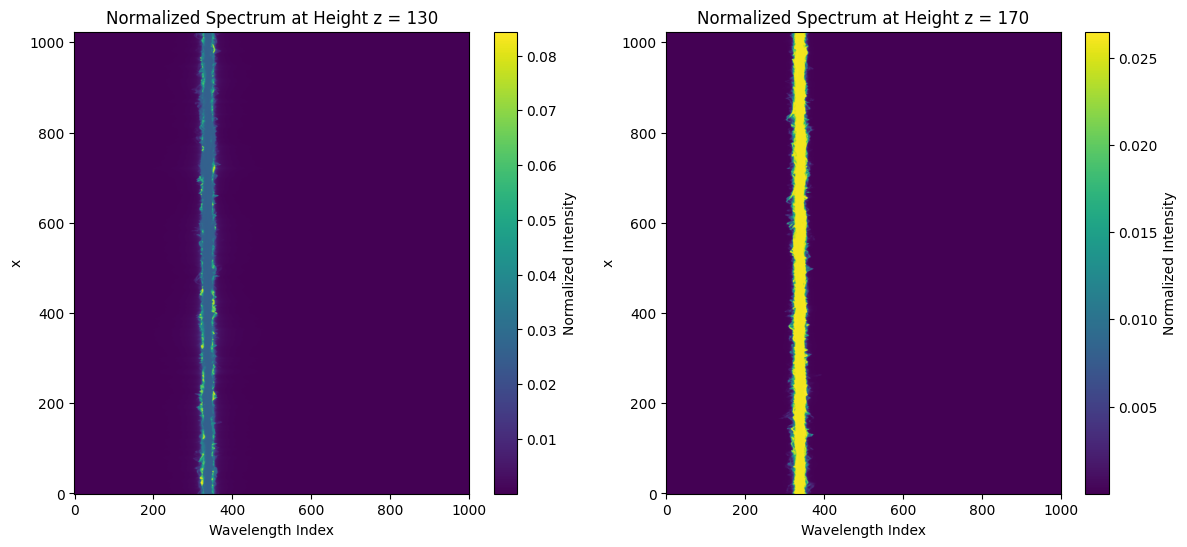

In [23]:
# Plot a couple of the normalized spectra in the I(x, z = const, lambda), at two different heights:

heights = [130, 170]  # Example heights
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)  # First subplot for the first height
plt.imshow(spectrum_ssd[:, heights[0], :], aspect='auto', origin='lower')
plt.colorbar(label='Normalized Intensity')
plt.ylabel('x')
plt.xlabel('Wavelength Index')
plt.title(f'Normalized Spectrum at Height z = {heights[0]}')

plt.subplot(1, 2, 2)  # Second subplot for the second height
plt.imshow(spectrum_ssd[:, heights[1], :], aspect='auto', origin='lower')
plt.colorbar(label='Normalized Intensity')
plt.ylabel('x')
plt.xlabel('Wavelength Index')
plt.title(f'Normalized Spectrum at Height z = {heights[1]}')

In [22]:
# Our idea is to relate the shape of the spectrum to the atmosphere along the line of sight.
# That atmosphere is hidden in: 

atmos_model = h5py.File('/dat/milic/SUSI_modeling/atm_extended_ssd_angle_80.h5', 'r')
atmos_model.keys()

<KeysViewHDF5 ['Electron_density', 'LOS_velocity', 'Population_lower_level', 'Population_upper_level', 'Pressure', 'Temperature', 'x_coords_grid', 'x_coords_grid_in_box', 'y_coords_grid', 'y_coords_grid_in_box']>

Text(0.5, 1.0, 'Normalized Spectrum at x = 200, z = 130')

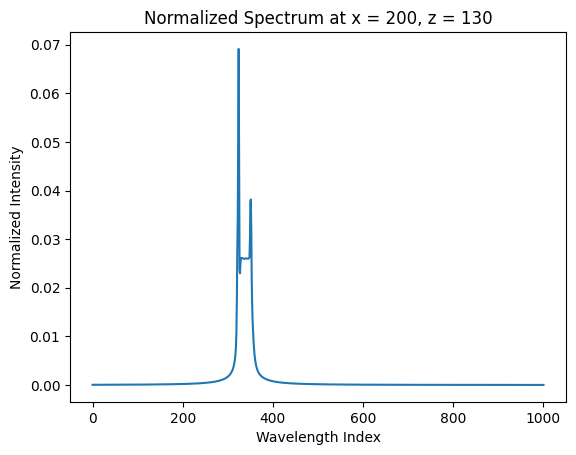

In [25]:
# For example, pick x and z indices, call them i and k 
i = 200
k = 130
plt.plot(spectrum_ssd[i, k, :])
plt.xlabel('Wavelength Index')
plt.ylabel('Normalized Intensity')
plt.title(f'Normalized Spectrum at x = {i}, z = {k}')
#plt.show()

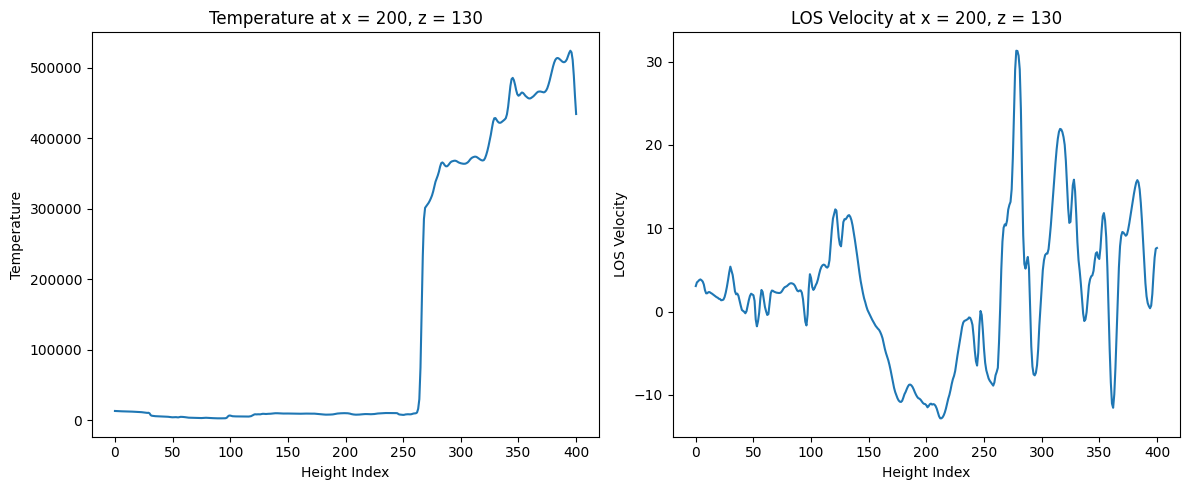

In [ ]:
# We can now extract the model atmosphere that produced this spectrum 
# For example, let's plot the tmeperature and the LOS velocity as they are the most important: 
T_los = atmos_model['Temperature'][i, k, :]
v_los = atmos_model['LOS_velocity'][i, k, :]
pop_l_los = atmos_model['Population_lower_level'][i, k, :]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)  # First subplot for temperature
plt.semilogy(pop_l_los)
plt.xlabel('Height Index')
plt.ylabel('Temperature')
plt.title(f'Temperature at x = {i}, z = {k}')

plt.subplot(1, 2, 2)  # Second subplot for LOS velocity
plt.plot(v_los/1e5)
plt.xlabel('Height Index')
plt.ylabel('LOS Velocity')
plt.title(f'LOS Velocity at x = {i}, z = {k}')
plt.tight_layout()
plt.show()